En İyi Eşik Değeri: 0.50
              precision    recall  f1-score   support

    Negative       0.96      0.94      0.95       938
    Positive       0.69      0.76      0.73       158

    accuracy                           0.92      1096
   macro avg       0.83      0.85      0.84      1096
weighted avg       0.92      0.92      0.92      1096



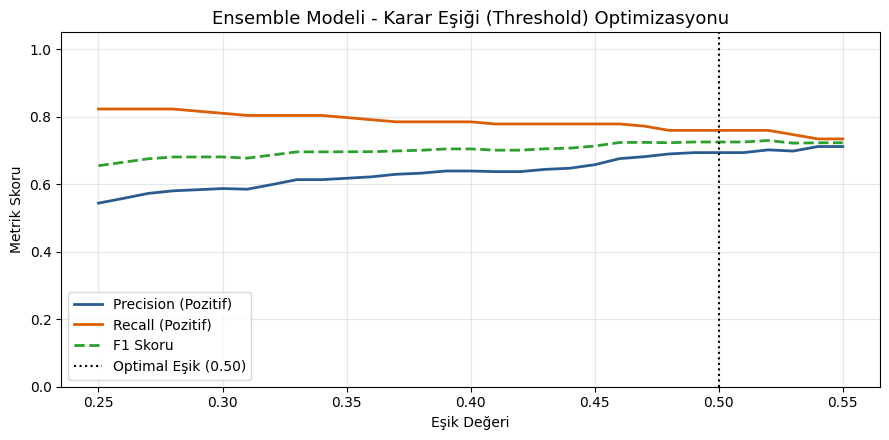

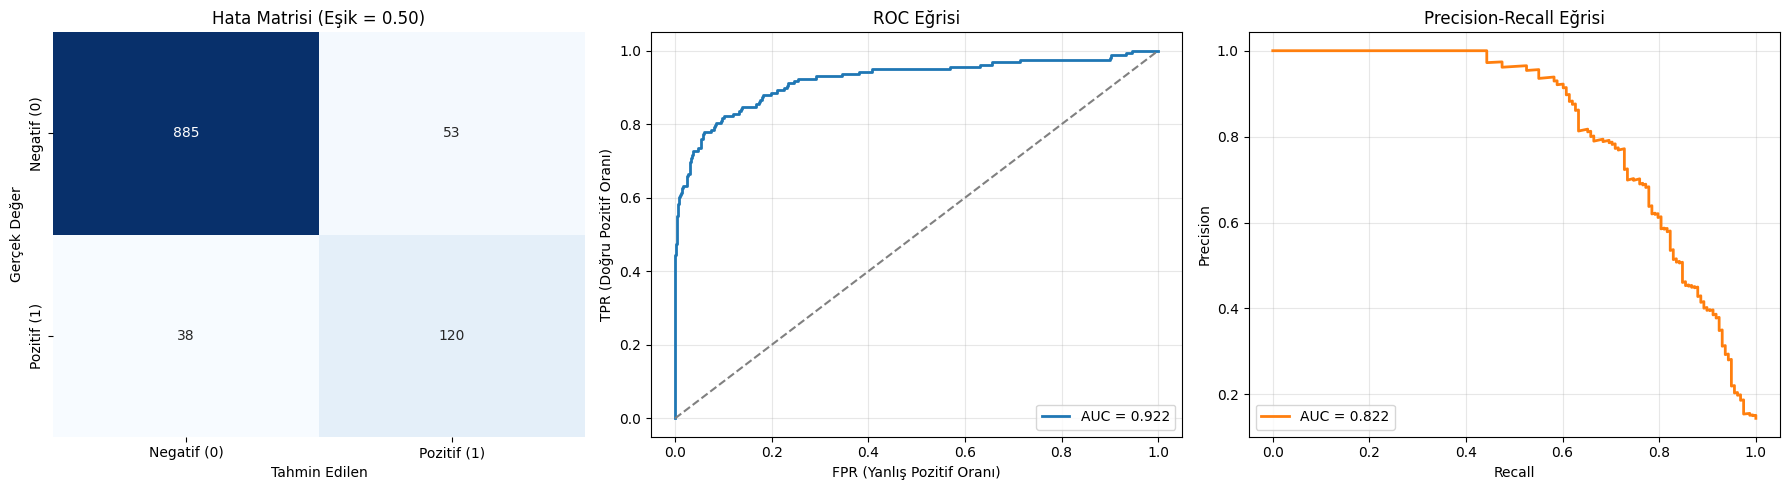

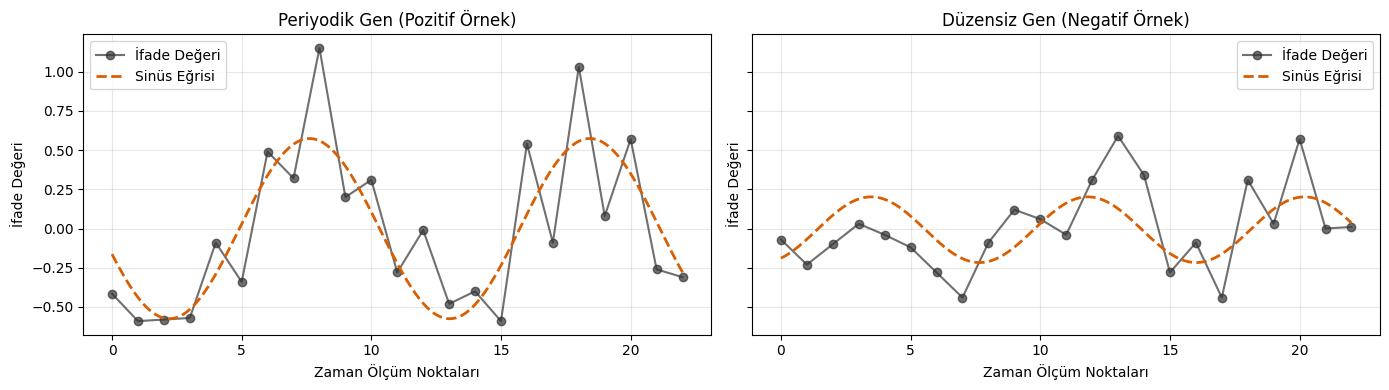

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc, precision_recall_curve, precision_recall_fscore_support
)
import xgboost as xgb
from imblearn.combine import SMOTETomek
import joblib
import warnings
warnings.filterwarnings('ignore')

os.makedirs("/content/results/figures", exist_ok=True)
os.makedirs("/content/models", exist_ok=True)

# 1. Veri Yükle
df = pd.read_csv("/content/Spellman_with_labels.csv")
orf_col = df.columns[0]
time_cols = [col for col in df.columns if col not in [orf_col, 'label']]
X_raw = df[time_cols].values.astype(float)
y = df['label'].values
t = np.arange(len(time_cols))

# 2. İleri Seviye Özellik Çıkarımı
def extract_advanced_features(X, t):
    features = {}
    features['mean'] = np.mean(X, axis=1)
    features['std']  = np.std(X, axis=1)
    features['max']  = np.max(X, axis=1)
    features['min']  = np.min(X, axis=1)
    features['range'] = features['max'] - features['min']

    fft_vals = np.abs(np.fft.fft(X, axis=1))
    n = X.shape[1]
    features['fft_power_low']  = np.sum(fft_vals[:, 1:5], axis=1)
    features['fft_power_mid']  = np.sum(fft_vals[:, 5:12], axis=1)
    features['fft_power_high'] = np.sum(fft_vals[:, 12:n//2], axis=1)
    features['fft_total']      = np.sum(fft_vals[:, 1:n//2], axis=1)
    features['dominant_freq']  = np.argmax(fft_vals[:, 1:n//2], axis=1)

    def autocorr(x):
        result = np.correlate(x - np.mean(x), x - np.mean(x), mode='full')
        return result[result.size//2:] / (np.std(x)**2 * len(x))

    ac = np.array([autocorr(row) for row in X])
    features['autocorr_lag1'] = ac[:, 1]
    features['autocorr_lag2'] = ac[:, 2] if ac.shape[1] > 2 else 0
    features['num_peaks'] = np.array([len(find_peaks(row, prominence=0.3)[0]) for row in X])

    def sine_func(t, amp, freq, phase, offset):
        return amp * np.sin(2 * np.pi * freq * t + phase) + offset

    sine_params = []
    for row in X:
        try:
            popt, _ = curve_fit(sine_func, t, row, p0=[1.0, 0.1, 0, 0], maxfev=5000)
            sine_params.append(popt)
        except Exception:
            sine_params.append([0, 0.1, 0, np.mean(row)])

    sine_params = np.array(sine_params)
    features['sine_amp']    = sine_params[:, 0]
    features['sine_freq']   = sine_params[:, 1]
    features['sine_phase']  = sine_params[:, 2]
    features['sine_offset'] = sine_params[:, 3]
    return pd.DataFrame(features)

X = extract_advanced_features(X_raw, t)

# 3. SMOTE-Tomek & Train/Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
smotetomek = SMOTETomek(random_state=42)
X_train_bal, y_train_bal = smotetomek.fit_resample(X_train, y_train)

# 4. Ensemble Model Eğitimi
rf = RandomForestClassifier(n_estimators=600, max_depth=14, min_samples_leaf=1,
                            class_weight='balanced_subsample', random_state=42, n_jobs=-1)

xgb_model = xgb.XGBClassifier(n_estimators=400, learning_rate=0.08, max_depth=8,
                              subsample=0.9, colsample_bytree=0.9, random_state=42,
                              eval_metric='logloss',
                              scale_pos_weight=len(y_train_bal[y_train_bal==0])/len(y_train_bal[y_train_bal==1]))

ensemble = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb_model)], voting='soft')
ensemble.fit(X_train_bal, y_train_bal)

# 5. Threshold Taraması
proba = ensemble.predict_proba(X_test)[:, 1]
best_threshold, best_f1, best_recall, best_precision = 0.5, 0, 0, 0
thresholds = np.arange(0.25, 0.55, 0.01)
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    y_pred_t = (proba >= thresh).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred_t, average=None, labels=[1], zero_division=0)
    precisions.append(p[0])
    recalls.append(r[0])
    f1s.append(f[0])

    if r[0] >= 0.85 and (f[0] > best_f1 or (r[0] > best_recall and p[0] > best_precision)):
        best_threshold = thresh
        best_f1 = f[0]
        best_recall = r[0]
        best_precision = p[0]

y_pred_final = (proba >= best_threshold).astype(int)
print(f"En İyi Eşik Değeri: {best_threshold:.2f}")
print(classification_report(y_test, y_pred_final, target_names=['Negative', 'Positive']))

# Modeli kaydet
joblib.dump(ensemble, "/content/models/spellman_periodic_classifier_ensemble.pkl")

# ====================== GÖRSELLEŞTİRME 1: THRESHOLD TARAMASI ======================
plt.figure(figsize=(9, 4.5))
plt.plot(thresholds, precisions, label="Precision (Pozitif)", color="#2b5c8f", lw=2)
plt.plot(thresholds, recalls, label="Recall (Pozitif)", color="#d95f02", lw=2)
plt.plot(thresholds, f1s, label="F1 Skoru", color="#2ca02c", lw=2, linestyle="--")
plt.axvline(best_threshold, color="black", linestyle=":", label=f"Optimal Eşik ({best_threshold:.2f})")
plt.title("Ensemble Modeli - Karar Eşiği (Threshold) Optimizasyonu", fontsize=13)
plt.xlabel("Eşik Değeri")
plt.ylabel("Metrik Skoru")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("/content/results/figures/threshold_optimization.png", dpi=300)
plt.show()

# ====================== GÖRSELLEŞTİRME 2: CM, ROC ve PR ======================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Negatif (0)", "Pozitif (1)"], yticklabels=["Negatif (0)", "Pozitif (1)"])
axes[0].set_title(f"Hata Matrisi (Eşik = {best_threshold:.2f})")
axes[0].set_xlabel("Tahmin Edilen")
axes[0].set_ylabel("Gerçek Değer")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="#1f77b4", lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], color="grey", linestyle="--")
axes[1].set_title("ROC Eğrisi")
axes[1].set_xlabel("FPR (Yanlış Pozitif Oranı)")
axes[1].set_ylabel("TPR (Doğru Pozitif Oranı)")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

# 3. PR Curve
pr_prec, pr_rec, _ = precision_recall_curve(y_test, proba)
pr_auc = auc(pr_rec, pr_prec)
axes[2].plot(pr_rec, pr_prec, color="#ff7f0e", lw=2, label=f"AUC = {pr_auc:.3f}")
axes[2].set_title("Precision-Recall Eğrisi")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend(loc="lower left")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/results/figures/final_ensemble_evaluation.png", dpi=300)
plt.show()

# ====================== GÖRSELLEŞTİRME 3: SİNÜZOİDAL UYDURMA ÖRNEKLERİ ======================
pos_idx = np.where(y == 1)[0][0]
neg_idx = np.where(y == 0)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, idx, title in zip(axes, [pos_idx, neg_idx], ["Periyodik Gen (Pozitif Örnek)", "Düzensiz Gen (Negatif Örnek)"]):
    raw_signal = X_raw[idx]
    ax.plot(t, raw_signal, "o-", label="İfade Değeri", color="#333333", alpha=0.7)

    amp = X.loc[idx, "sine_amp"]
    freq = X.loc[idx, "sine_freq"]
    phase = X.loc[idx, "sine_phase"]
    offset = X.loc[idx, "sine_offset"]
    t_dense = np.linspace(0, len(t) - 1, 200)
    fitted_curve = amp * np.sin(2 * np.pi * freq * t_dense + phase) + offset

    ax.plot(t_dense, fitted_curve, "--", label="Sinüs Eğrisi", color="#d95f02", lw=2)
    ax.set_title(title)
    ax.set_xlabel("Zaman Ölçüm Noktaları")
    ax.set_ylabel("İfade Değeri")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("/content/results/figures/sinusoidal_fit_samples.png", dpi=300)
plt.show()